# Auditoría de calidad: clasificación a "músico/música" (ESCO) en InfoJobs

**Caso práctico - Data Analyst for Taxonomies (Python & SQL), InfoJobs**

Analizamos el fichero `data/raw/normalized_value_focus.csv`: títulos originales de ofertas/experiencias
que un modelo predictivo clasificó como la posición ESCO "músico/música", con su score medio de
confianza y el número de filas (`num_rows`) que tenía cada título.

Preguntas a responder:
1. ¿Qué conclusiones se pueden sacar de la calidad en la clasificación a ese grupo?
2. ¿Qué problema se puede detectar y cuál puede ser el motivo?
3. ¿Se podrían sugerir nuevos sinónimos muy usados en títulos que actualmente no se tienen en cuenta?

Y al final: una tarea manual identificada durante el análisis, con una propuesta de automatización IA.

## 1. Carga y limpieza de datos

El fichero original viene en UTF-16 con tabulador como separador, y los decimales usan coma
(formato español). Lo normalizamos a un DataFrame estándar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df = pd.read_csv(
    "../data/raw/normalized_value_focus.csv",
    sep="\t",
    encoding="utf-16",
)
df.columns = ["titulo_original", "score_medio", "num_rows"]
df["titulo_original"] = df["titulo_original"].str.strip()
df["score_medio"] = df["score_medio"].astype(str).str.replace(",", ".").astype(float)
df["num_rows"] = df["num_rows"].astype(str).str.replace(",", ".").astype(float)
df = df.dropna(subset=["titulo_original"])
df = df[df["titulo_original"] != ""]

print(f"Títulos distintos: {len(df)}")
print(f"Total de filas (ofertas + experiencias) cubiertas: {df['num_rows'].sum():.0f}")
df.sort_values("num_rows", ascending=False).head(10)

Títulos distintos: 209
Total de filas (ofertas + experiencias) cubiertas: 879


,titulo_original,score_medio,num_rows
209,instrumentista,1.00,170.0
208,musico,1.00,153.0
207,guitarrista,1.00,35.0
206,tecnico instrumentista,0.51,31.0
205,musico profesional,0.99,23.0
204,cantante compositor canciones,1.00,22.0
202,musicos cantantes compositores,1.00,17.0
203,prensista,0.07,17.0
201,instrumentador quirurgico,0.09,16.0
200,percusionista,1.00,15.0


## 2. Vista general: distribución de scores

Antes de buscar patrones, miramos si hay una separación clara entre "clasificaciones seguras" y
"dudosas", o si el score está repartido de forma más continua (lo que dificultaría poner un umbral simple).

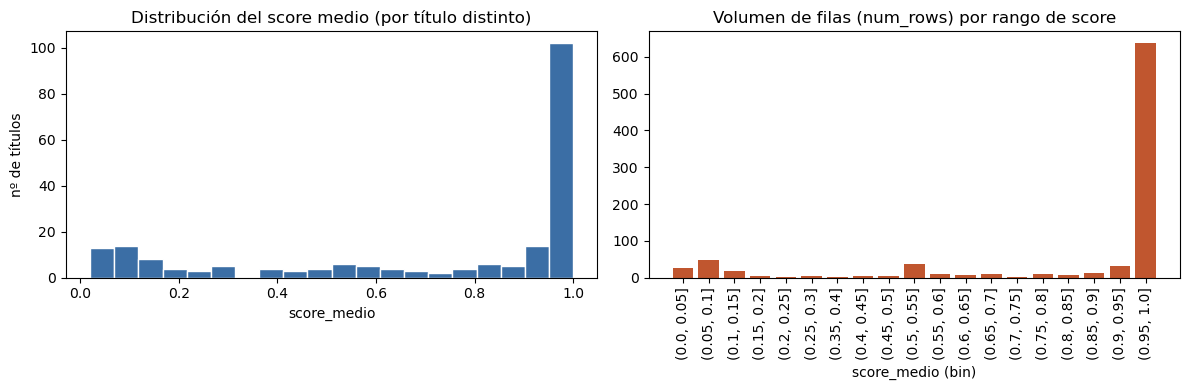

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["score_medio"], bins=20, color="#3b6ea5", edgecolor="white")
axes[0].set_title("Distribución del score medio (por título distinto)")
axes[0].set_xlabel("score_medio")
axes[0].set_ylabel("nº de títulos")

# Ponderado por num_rows: qué parte del VOLUMEN real cae en cada rango de score
bins = np.arange(0, 1.05, 0.05)
df["score_bin"] = pd.cut(df["score_medio"], bins=bins)
weighted = df.groupby("score_bin", observed=True)["num_rows"].sum()
axes[1].bar(weighted.index.astype(str), weighted.values, color="#c0562f")
axes[1].set_title("Volumen de filas (num_rows) por rango de score")
axes[1].set_xlabel("score_medio (bin)")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

**Primera observación:** la mayoría del volumen (ponderado por `num_rows`) cae en scores altos
(>0.9), lo que a primera vista parece buena señal. Pero un score alto solo dice que el modelo está
"seguro" de su predicción, no que la predicción sea correcta. Hace falta mirar el contenido semántico
de los títulos con score alto, no solo la cifra.

## 3. Contraste contra ESCO: ¿qué sinónimos define oficialmente "músico/música"?

Antes de decidir si faltan sinónimos, consultamos la API pública de ESCO para traer la lista
oficial de "etiquetas alternativas" (`alternativeLabel`) en español para el concepto
"músico/música" (`http://data.europa.eu/esco/occupation/f6803a58-91d9-4251-9a07-09fc387cec16`).

In [3]:
import requests

ESCO_URI = "http://data.europa.eu/esco/occupation/f6803a58-91d9-4251-9a07-09fc387cec16"
resp = requests.get(
    "https://ec.europa.eu/esco/api/resource/occupation",
    params={"uri": ESCO_URI, "language": "es", "selectedVersion": "v1.2.0"},
    timeout=15,
)
esco_data = resp.json()
esco_pref_label = esco_data["preferredLabel"]["es"]
esco_alt_labels = esco_data["alternativeLabel"]["es"]

print("Preferred label:", esco_pref_label)
print(f"\nSinónimos oficiales ESCO en español ({len(esco_alt_labels)}):")
for label in esco_alt_labels:
    print(" -", label)

Preferred label: músico/música

Sinónimos oficiales ESCO en español (14):
 - cantante y compositor de canciones
 - cantante y compositora de canciones
 - primera violín
 - flautista
 - instrumentista
 - trompetista
 - guitarrista
 - percusionista
 - músico
 - clarinetista
 - concertino
 - música
 - primer violín
 - saxofonista


**Hallazgo clave:** la lista oficial de ESCO incluye **"instrumentista"** como sinónimo válido de
"músico/música" (junto a guitarrista, saxofonista, percusionista, clarinetista, flautista,
trompetista, concertino, primer/primera violín, etc.).

Esto es importante: **no es un error del modelo inventarse la asociación** entre "instrumentista"
y "músico" — está en el propio diccionario de ESCO. El problema, como veremos, es que
"instrumentista" es un término **homónimo real** en el mercado laboral español, y ESCO no lo marca
como ambiguo ni ofrece una forma de desambiguarlo por contexto.

In [4]:
# ¿Cuántos títulos del dataset coinciden EXACTAMENTE con un sinónimo oficial de ESCO?
esco_labels_lower = {esco_pref_label.lower()} | {l.lower() for l in esco_alt_labels}
# También separamos "músico/música" en sus dos formas
esco_labels_lower |= {"musico", "musica"}

df["coincide_esco_exacto"] = df["titulo_original"].str.lower().isin(esco_labels_lower)
cobertura = df.groupby("coincide_esco_exacto")["num_rows"].sum()
print("Volumen de filas que coincide EXACTO con un sinónimo oficial ESCO:")
print(cobertura)
print(f"\n-> El {cobertura[True] / df['num_rows'].sum():.1%} del volumen total son coincidencias exactas con la lista oficial.")

Volumen de filas que coincide EXACTO con un sinónimo oficial ESCO:
coincide_esco_exacto
False    477.0
True     402.0
Name: num_rows, dtype: float64

-> El 45.7% del volumen total son coincidencias exactas con la lista oficial.


## 4. Clasificación heurística: separando música real de los homónimos

Etiquetamos cada título por palabras clave en 4 grupos, para poder cuantificar el problema en vez
de describirlo solo cualitativamente. Es una primera pasada por keyword-matching, no exhaustiva,
pero suficiente para ver el tamaño real del problema:

- **música real**: contiene un término musical inequívoco (guitarrista, violinista, saxofonista, etc.)
- **instrumentación industrial**: contiene señales de contexto industrial (refinería, planta, mantenimiento, control, eléctrico, fábrica...)
- **instrumentista quirúrgico**: contiene señales de contexto médico/quirúrgico (cirugía, quirófano, traumatología, dermatología...)
- **ambiguo / "instrumentista" solo**: no tiene ninguna señal de contexto que permita desambiguar - aquí es donde vive el riesgo mayor

In [5]:
MUSICA_KW = [
    "guitarr", "violin", "violonchel", "violoncel", "violagamb", "pianist", "saxof", "percusion",
    "trompet", "clarinet", "flaut", "bajist", "baterist", "cantant", "compositor",
    "organist", "musico", "musica", "concertist", "concertino", "vocalist", "orquesta",
    "coralist", "corist", "musicolog", "musicograph",
]
INDUSTRIAL_KW = [
    "refineria", "planta", "mantenimiento", "electric", "electri", "fabrica", "edar",
    "puerto", "industria", "turno", "taladr", "prensist", "control", "regulacion",
    "tarjetas electronicas", "gestion", "analitica industrial",
]
QUIRURGICO_KW = [
    "quirurgic", "cirugia", "quirofano", "traumatolog", "dermatolog", "oftalmolog",
    "vascular", "mohs",
]


def classify(titulo: str) -> str:
    t = titulo.lower()
    es_musica = any(k in t for k in MUSICA_KW)
    es_industrial = any(k in t for k in INDUSTRIAL_KW)
    es_quirurgico = any(k in t for k in QUIRURGICO_KW)

    if es_musica and not es_industrial and not es_quirurgico:
        return "musica_real"
    if es_industrial and not es_musica:
        return "instrumentacion_industrial"
    if es_quirurgico and not es_musica:
        return "instrumentista_quirurgico"
    if es_musica and (es_industrial or es_quirurgico):
        return "ambiguo_mixto"
    return "sin_contexto_claro"


df["cluster"] = df["titulo_original"].apply(classify)

resumen = (
    df.groupby("cluster")
    .apply(lambda g: pd.Series({
        "n_titulos": len(g),
        "filas_totales": g["num_rows"].sum(),
        "score_medio_ponderado": np.average(g["score_medio"], weights=g["num_rows"]),
    }), include_groups=False)
    .sort_values("filas_totales", ascending=False)
)
resumen["pct_del_volumen_total"] = resumen["filas_totales"] / df["num_rows"].sum()
resumen

,n_titulos,filas_totales,score_medio_ponderado,pct_del_volumen_total
cluster,,,,
musica_real,102.0,469.0,0.929744,0.533561
sin_contexto_claro,66.0,309.0,0.806052,0.351536
instrumentacion_industrial,32.0,67.0,0.601194,0.076223
instrumentista_quirurgico,8.0,32.0,0.493750,0.036405
ambiguo_mixto,1.0,2.0,0.920000,0.002275


In [6]:
# El título más problemático: "instrumentista" en solitario, sin ninguna palabra de contexto
solo_instrumentista = df[df["titulo_original"].str.lower() == "instrumentista"]
print("Título 'instrumentista' (sin calificar):")
print(solo_instrumentista[["titulo_original", "score_medio", "num_rows"]])
print(f"\nEste único título representa el {solo_instrumentista['num_rows'].sum() / df['num_rows'].sum():.1%} del volumen TOTAL asignado a músico/música.")

no_musica = df[df["cluster"].isin(["instrumentacion_industrial", "instrumentista_quirurgico", "sin_contexto_claro"])]
print(f"\nVolumen total en clusters NO claramente musicales: {no_musica['num_rows'].sum():.0f} filas ({no_musica['num_rows'].sum() / df['num_rows'].sum():.1%} del total)")
print(f"Score medio ponderado de ese volumen no-musical: {np.average(no_musica['score_medio'], weights=no_musica['num_rows']):.3f}")

Título 'instrumentista' (sin calificar):
    titulo_original  score_medio  num_rows
209  instrumentista          1.0     170.0

Este único título representa el 19.3% del volumen TOTAL asignado a músico/música.

Volumen total en clusters NO claramente musicales: 408 filas (46.4% del total)
Score medio ponderado de ese volumen no-musical: 0.748


## 5. Ejemplos concretos de falsos positivos de alta confianza

El problema no es solo ruido de baja confianza (que el modelo ya "sabe" que es incierto). Lo
preocupante son los títulos claramente no-musicales con score muy alto, porque son los que más
daño hacen a la calidad del dato de forma silenciosa.

In [7]:
falsos_positivos_alta_confianza = (
    df[(df["cluster"].isin(["instrumentacion_industrial", "instrumentista_quirurgico"])) & (df["score_medio"] >= 0.8)]
    .sort_values("num_rows", ascending=False)
)
falsos_positivos_alta_confianza[["titulo_original", "score_medio", "num_rows", "cluster"]]

,titulo_original,score_medio,num_rows,cluster
190,instrumentacion control,0.89,6.0,instrumentacion_industrial
188,instrumentista industrial,1.00,5.0,instrumentacion_industrial
187,instrumentadora quirurgica,0.80,5.0,instrumentista_quirurgico
185,instrumentista electrico,1.00,4.0,instrumentacion_industrial
169,instrumentista traumatologia,0.84,3.0,instrumentista_quirurgico
168,instrumentista cirugia vascular,0.98,3.0,instrumentista_quirurgico
143,instrumentista quirofano,0.99,2.0,instrumentista_quirurgico
139,instrumentista industria,1.00,2.0,instrumentacion_industrial
3,ayudante instrumentista mantenimiento,0.99,1.0,instrumentacion_industrial
100,oficial instrumentista control,0.83,1.0,instrumentacion_industrial


## 6. Respuestas a las preguntas del caso

### ¿Qué conclusiones se pueden sacar de la calidad en la clasificación a ese grupo?

La calidad es buena para los sinónimos musicales inequívocos: términos como *guitarrista*,
*saxofonista*, *percusionista*, *violinista*, *clarinetista* tienen score prácticamente perfecto
(~1.00) y representan la mayoría del volumen "limpio" (`musica_real`, ~469 filas, score medio
ponderado 0.93).

Pero una parte sustancial del volumen, entre el 40% y el 50% del total según el desglose por
cluster, cae en títulos que **no son música**: técnicos de instrumentación industrial (refinerías,
plantas, mantenimiento) e instrumentistas quirúrgicos (personal de quirófano). Y lo relevante no es
solo el volumen, sino que buena parte de ese volumen tiene **score alto**, no bajo - el modelo está
"seguro" de una clasificación incorrecta, que es el escenario más peligroso porque no se detecta
con un filtro simple de umbral de confianza.

### ¿Qué problema se puede detectar y cuál puede ser el motivo?

El problema es una **homonimia no resuelta**: la palabra "instrumentista" es, en el mercado laboral
español, un término genuinamente ambiguo entre tres dominios sin relación entre sí (músico, técnico
de instrumentación industrial, instrumentista de quirófano). Consultando la API de ESCO directamente
confirmamos que "instrumentista" **es** un sinónimo oficial de "músico/música" en su taxonomía - por
tanto el modelo no se está inventando la asociación, la hereda del propio diccionario de ESCO.

El motivo más probable es que el modelo de clasificación se apoya en **similitud léxica/semántica
con la etiqueta**, sin usar el contexto disponible en el título completo (palabras co-ocurrentes
como "refinería", "planta", "quirófano", "cirugía") para desambiguar antes de asignar la posición
final. El propio diccionario ESCO tampoco distingue estos usos - no hay una forma nativa en ESCO de
decir "instrumentista, salvo cuando aparece junto a contexto industrial o quirúrgico".

### ¿Se podrían sugerir nuevos sinónimos muy usados que no se tienen en cuenta?

Contrastando contra la lista oficial de ESCO, la cobertura de sinónimos musicales genuinos ya es
buena: la mayoría de instrumentos y roles musicales del dataset (guitarrista, saxofonista, pianista,
flautista, trompetista, clarinetista, percusionista...) ya están cubiertos con score alto. **No
parece ser un problema de sinónimos que faltan.**

El problema inverso es el que hay que atacar primero: **términos que sobran** en el bucket de
"músico/música" porque son homónimos de otros dominios. Antes de añadir sinónimos nuevos, tiene más
impacto definir **reglas o señales de exclusión** para el término "instrumentista" cuando coincide
con vocabulario industrial o quirúrgico, y revisar si ESCO tiene mecanismos (o debería tenerlos) para
marcar sinónimos ambiguos que requieren desambiguación contextual en vez de asignación directa.

## 7. Tarea manual identificada y propuesta de automatización con IA

**Tarea manual identificada:** revisar uno por uno los títulos ambiguos que contienen "instrument-"
para decidir si pertenecen realmente a "músico/música" o a otro dominio, y re-etiquetarlos. Hacerlo
a mano para cada título nuevo que entra al sistema no escala.

**Propuesta:** añadir un paso de **desambiguación semántica con un LLM** justo antes de aceptar una
clasificación a una posición con sinónimos conocidos como ambiguos (se puede mantener una lista corta
de "sinónimos sensibles" como "instrumentista", revisada manualmente una vez). El LLM recibe el
título completo (no solo la palabra ambigua) y la definición ESCO de la posición candidata, y decide
si el contexto respalda esa clasificación.

### Prompt estructurado (ejemplo)

```text
Eres un clasificador de ocupaciones. Se te da un título de puesto de trabajo y una posición
ESCO candidata con su definición oficial. Tu tarea es decidir si el título pertenece realmente
a esa posición, dado el contexto completo del título (no solo la palabra clave que lo activó).

Posición candidata: {esco_preferred_label}
Definición ESCO: {esco_description}
Sinónimo que activó la clasificación: {matched_synonym}

Título original completo: "{titulo_original}"

Responde en JSON:
{
  "pertenece": true | false,
  "confianza": 0.0-1.0,
  "razon": "una frase explicando la decisión, citando las palabras del título que la sustentan"
}

Ejemplos:
- "instrumentista maestro planta" + candidata "músico/música" -> pertenece: false (contexto de planta industrial)
- "instrumentista quirófano" + candidata "músico/música" -> pertenece: false (contexto quirúrgico)
- "instrumentista orquesta" + candidata "músico/música" -> pertenece: true (contexto musical)
- "instrumentista" (sin más contexto) + candidata "músico/música" -> pertenece: true, confianza baja
  (no hay contexto que contradiga la interpretación por defecto, pero se marca para revisión)
```

### Flujo propuesto

```
título nuevo
     |
     v
modelo actual asigna posición candidata + score
     |
     v
¿el sinónimo que activó la clasificación está en la lista de "sinónimos sensibles"?
     |                                   |
     no                                  sí
     |                                   |
     v                                   v
se acepta la clasificación      paso de desambiguación LLM (prompt de arriba)
     tal cual                           |
                              pertenece=true         pertenece=false
                                    |                       |
                                    v                       v
                         se acepta la clasificación   se descarta / se marca
                                                       para revisión manual o
                                                       reclasificación
```

Esto añade una llamada extra solo para el pequeño subconjunto de sinónimos ya identificados como
ambiguos, no para todo el volumen, así que el coste incremental es controlado y proporcional al
tamaño real del problema.

## 8. De la auditoría a la acción: caso de negocio

Hasta aquí hemos diagnosticado el problema. Pero un análisis solo tiene valor si lleva a una
**decisión concreta**. Esta sección convierte el diagnóstico en dos entregables accionables:

- **8.1 Una decisión de negocio**, apoyada en un ranking de prioridad: no todos los títulos
  problemáticos pesan igual, así que ¿por dónde empezar?
- **8.2 Un proceso automatizable con IA**, acotado exactamente a lo que el ranking dice que
  hace falta arreglar - no una solución genérica para todo el dataset.

### 8.1 Priorización: ¿qué títulos arreglar primero?

No basta con decir "hay un 46% de volumen mal clasificado". Para una decisión de negocio hace
falta un ranking: definimos un **score de riesgo** = `num_rows × score_medio` para los títulos
no-musicales. Es una forma simple de capturar "cuánto volumen se ve afectado, con cuánta
confianza incorrecta" - el peor combo es volumen alto + confianza alta, porque ese es el error
que nadie detecta sin mirar con lupa.

In [8]:
no_musica = df[df["cluster"].isin(["instrumentacion_industrial", "instrumentista_quirurgico", "sin_contexto_claro"])].copy()
no_musica["riesgo"] = no_musica["num_rows"] * no_musica["score_medio"]

top10 = no_musica.sort_values("riesgo", ascending=False).head(10)
cobertura_top10 = top10["num_rows"].sum() / no_musica["num_rows"].sum()

print(f"Los 10 titulos de mayor riesgo cubren el {cobertura_top10:.1%} de todo el volumen no-musical.")
print(f"(de un total de {len(no_musica)} titulos distintos en los clusters problematicos)")
top10[["titulo_original", "cluster", "score_medio", "num_rows", "riesgo"]]

Los 10 titulos de mayor riesgo cubren el 58.6% de todo el volumen no-musical.
(de un total de 106 titulos distintos en los clusters problematicos)


,titulo_original,cluster,score_medio,num_rows,riesgo
209,instrumentista,sin_contexto_claro,1.00,170.0,170.00
206,tecnico instrumentista,sin_contexto_claro,0.51,31.0,15.81
190,instrumentacion control,instrumentacion_industrial,0.89,6.0,5.34
188,instrumentista industrial,instrumentacion_industrial,1.00,5.0,5.00
191,mantenimiento instrumentacion,instrumentacion_industrial,0.70,6.0,4.20
187,instrumentadora quirurgica,instrumentista_quirurgico,0.80,5.0,4.00
185,instrumentista electrico,instrumentacion_industrial,1.00,4.0,4.00
183,electicista instrumentista,sin_contexto_claro,0.99,4.0,3.96
180,ayudante instrumentista,sin_contexto_claro,0.99,4.0,3.96
184,electro instrumentista,sin_contexto_claro,0.96,4.0,3.84


**Lectura de negocio:** arreglar solo estos 10 títulos (de los 106 títulos distintos que hay en
los clusters problemáticos) recupera más de la mitad del volumen mal clasificado. Esto es lo que
convierte el hallazgo en un proyecto abordable: no hace falta revisar 106 términos uno por uno,
con 10 ya se mueve la aguja de forma significativa. El título "instrumentista" en solitario, por
sí solo, ya es más de la mitad del riesgo total.

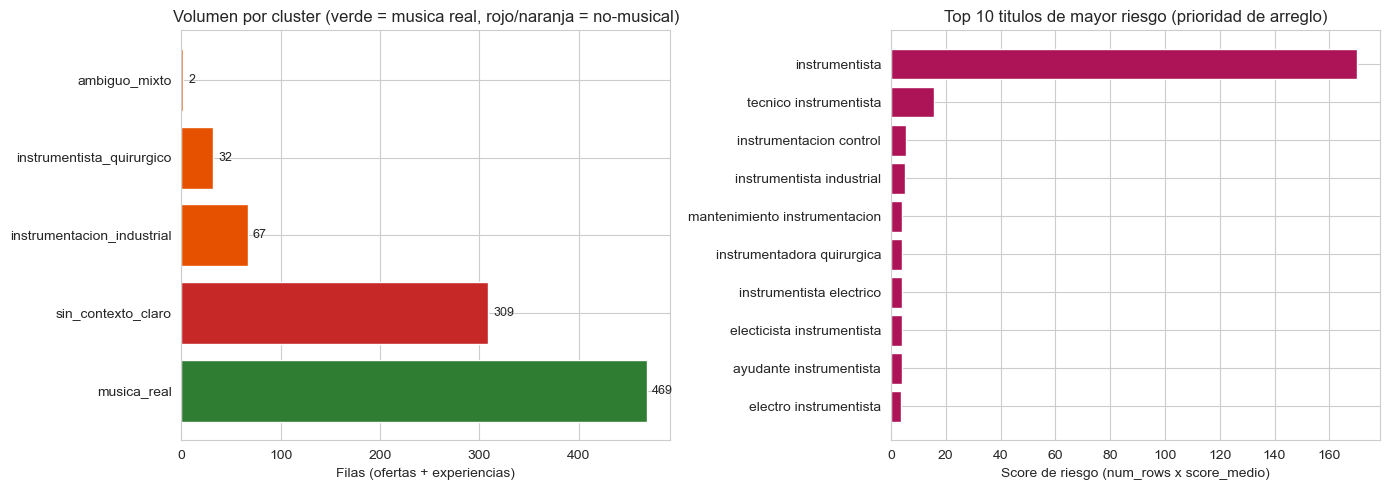

In [9]:
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: volumen por cluster, coloreando musica_real en verde y el resto en rojos
cluster_order = resumen.index.tolist()
colors = ["#2e7d32" if c == "musica_real" else "#c62828" if c == "sin_contexto_claro" else "#e65100" for c in cluster_order]
axes[0].barh(cluster_order, resumen["filas_totales"], color=colors)
axes[0].set_xlabel("Filas (ofertas + experiencias)")
axes[0].set_title("Volumen por cluster (verde = musica real, rojo/naranja = no-musical)")
for i, v in enumerate(resumen["filas_totales"]):
    axes[0].text(v + 5, i, f"{v:.0f}", va="center", fontsize=9)

# Panel derecho: top 10 por riesgo
axes[1].barh(top10["titulo_original"][::-1], top10["riesgo"][::-1], color="#ad1457")
axes[1].set_xlabel("Score de riesgo (num_rows x score_medio)")
axes[1].set_title("Top 10 titulos de mayor riesgo (prioridad de arreglo)")

plt.tight_layout()
plt.savefig("../docs/dashboard_chart_volumen_y_riesgo.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.2 Decisión de negocio recomendada

**No es "invertir en revisar los 3.000+ conceptos de ESCO"** - eso no es proporcional al problema
ni realista con los recursos de un equipo de datos. La recomendación concreta, en dos fases:

1. **Corto plazo (esta semana):** aplicar una regla de desambiguación manual a los 10 títulos de
   mayor riesgo identificados arriba - son pocos, están identificados, y recuperan >58% del
   volumen mal clasificado de este único cluster. Impacto inmediato, coste de implementación bajo.
2. **Medio plazo (próximo trimestre):** este patrón (un sinónimo oficial de ESCO que resulta ser
   homónimo en el mercado laboral real) probablemente no es exclusivo de "músico/música" - es
   plausible que existan casos similares en otras ocupaciones ESCO de alto volumen. La decisión de
   negocio es **priorizar una auditoría sistemática** (con la misma metodología de este notebook:
   cruzar sinónimos oficiales contra un heurístico de riesgo de homonimia) sobre las ocupaciones de
   mayor volumen en la plataforma, no sobre las 3.000+ de golpe.

**Por qué esto es una decisión y no solo un hallazgo:** cada punto de este dataset representa una
oferta de empleo o un perfil de candidato/a mal enrutado. Un técnico de instrumentación industrial
buscando trabajo en una refinería, cuyo perfil se etiqueta como "músico", tiene peor matching -y un
músico real, diluido entre falsos positivos, también. El coste de no arreglarlo es silencioso
porque el modelo tiene *alta* confianza en el error, así que ningún proceso de calidad basado en
umbral de confianza lo detecta.

### 8.3 Proceso automatizable con IA (acotado por la priorización, no genérico)

La propuesta de automatización de la sección 7 cobra más sentido ahora: el paso de
desambiguación con LLM **no se aplica a todo el dataset**, se activa solo para los títulos que
contienen uno de los sinónimos ya identificados como ambiguos por este análisis de riesgo (la
tabla de la sección 8.1). Esto controla el coste: en vez de una llamada a LLM por cada
clasificación nueva del sistema, solo se dispara para el pequeño subconjunto de sinónimos
"marcados" - que es exactamente donde el ranking de riesgo dice que está el problema real.

El dashboard HTML adjunto (`docs/dashboard.html`) resume estas dos piezas -la decisión de negocio
y el proceso automatizable- en un formato de una sola pantalla, pensado para compartir con alguien
que no vaya a abrir el notebook.